# **Guía de Actividades Práctico-Experimentales Nro. 008**

---

## **1. Datos Generales**

| **Atributo** | **Descripción** |
| :--- | :--- |
| **Estudiantes** | Kiara Condoy, Héctor Guerrero, Javier Guarnizo, Ricardo Ochoa, Emily Salas |
| **Asignatura** | Teoría de la Distribución y Probabilidad |
| **Ciclo** | 2do “A” |
| **Unidad** | 1 |
| **Práctica Nro.** | 008 |
| **Título de la Práctica** | **Inferencia Estadística: Estimación de Parámetros e Intervalos de Confianza (Z y T de Student)**|
| **Nombre del Docente** | Cristian Ramiro Narváez Guillén |
| **Fecha** | Martes 02 de junio 2026 |

---



# **Tarea 1: Intervalos de Confianza para Muestras Grandes (Distribución Z)**


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t
# 1. Datos de la muestra (Consumo energético en kWh)
np.random.seed(42)
n_grande = 100
muestra_consumo = np.random.normal(loc=350, scale=45, size=n_grande)
# 2. Estadísticos descriptivos (Estimadores puntuales)
media_muestral = np.mean(muestra_consumo)
desv_estandar = np.std(muestra_consumo, ddof=1) # s (muestral)
error_estandar = desv_estandar / np.sqrt(n_grande) # SE
# 3. Cálculo del Intervalo de Confianza (95%)
nivel_confianza = 0.95
# loc = media muestral, scale = error estándar de la media
ic_inferior_z, ic_superior_z = norm.interval(confidence=nivel_confianza,
loc=media_muestral,
scale=error_estandar)
margen_error_z = (ic_superior_z - ic_inferior_z) / 2
print("--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---")
print(f"Tamaño de muestra (n): {n_grande}")
print(f"Media Muestral (Estimador puntual): {media_muestral:.2f} kWh")
print(f"Margen de Error: ±{margen_error_z:.2f} kWh")
print(f"IC al {nivel_confianza*100}%: [{ic_inferior_z:.2f}, {ic_superior_z:.2f}] kWh")

--- Intervalo de Confianza (Distribución Z - Muestra Grande) ---
Tamaño de muestra (n): 100
Media Muestral (Estimador puntual): 345.33 kWh
Margen de Error: ±8.01 kWh
IC al 95.0%: [337.32, 353.34] kWh


# **Tarea 2: Intervalos para Muestras Pequeñas (Distribución T de Student)**


In [ ]:
# Muestra pequeña (n=12)
n_pequena = 12
muestra_agua = np.random.normal(loc=7.2, scale=0.5, size=n_pequena) # pH del agua
media_t = np.mean(muestra_agua)
error_estandar_t = np.std(muestra_agua, ddof=1) / np.sqrt(n_pequena)
grados_libertad = n_pequena - 1
# IC usando T de Student
ic_inf_t, ic_sup_t = t.interval(confidence=0.95, df=grados_libertad,
loc=media_t, scale=error_estandar_t)
print(f"IC (T de Student, 95%): [{ic_inf_t:.3f}, {ic_sup_t:.3f}]")

IC (T de Student, 95%): [6.976, 7.692]


# **Tarea 3: Hito del Proyecto - Estimación de la Realidad Regional (ABP)**





In [ ]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 1. Cargar el dataset
url = 'https://docs.google.com/spreadsheets/d/1E-rrTgcTIWS-UnuVf1ldKvhDkwT6uUgh/export?format=xlsx'
df = pd.read_excel(url, sheet_name='Subnational 1 tree cover loss')
display(df.head(15))
df = df.dropna(how='all').reset_index(drop=True)

,country,subnational1,threshold,area_ha,extent_2000_ha,extent_2010_ha,gain_2000-2012_ha,tc_loss_ha_2001,tc_loss_ha_2002,tc_loss_ha_2003,...,tc_loss_ha_2015,tc_loss_ha_2016,tc_loss_ha_2017,tc_loss_ha_2018,tc_loss_ha_2019,tc_loss_ha_2020,tc_loss_ha_2021,tc_loss_ha_2022,tc_loss_ha_2023,tc_loss_ha_2024
0,Ecuador,Azuay,0,816926,816926,816926,5887,1859,340,342,...,370,606,457,289,347,272,189,322,291,385
1,Ecuador,Azuay,10,816926,428633,484716,5887,1804,337,331,...,351,557,416,269,304,249,152,258,202,285
2,Ecuador,Azuay,15,816926,409481,472186,5887,1801,335,329,...,347,548,409,265,299,244,149,248,192,272
3,Ecuador,Azuay,20,816926,398952,464049,5887,1788,334,328,...,344,545,405,263,297,243,148,246,188,267
4,Ecuador,Azuay,25,816926,391864,450921,5887,1781,334,327,...,343,541,403,261,296,242,145,244,186,263
5,Ecuador,Azuay,30,816926,383423,435249,5887,1776,333,324,...,341,537,400,259,294,241,143,240,183,259
6,Ecuador,Azuay,50,816926,316850,328208,5887,1686,324,300,...,320,495,368,242,275,218,130,213,155,219
7,Ecuador,Azuay,75,816926,208116,237227,5887,1497,296,256,...,270,377,275,194,192,167,90,146,92,148
8,Ecuador,Bolivar,0,389964,389964,389964,4089,337,371,86,...,163,248,171,327,335,140,79,169,306,268
9,Ecuador,Bolivar,10,389964,253342,261961,4089,332,369,85,...,68,136,98,232,216,80,35,108,187,186


In [ ]:
# 2. SELECCIÓN DE VARIABLE CUANTITATIVA Y EXTRACCIÓN DE MUESTRA
variable_cuantitativa = 'tc_loss_ha_2024'
datos_poblacion = df[variable_cuantitativa].dropna()

# Extraemos una muestra aleatoria
n = 25
muestra = datos_poblacion.sample(n=n, random_state=42)

In [ ]:
# 3. Cálculos estadísticos muestrales
media_muestral = muestra.mean()
s_muestral = muestra.std(ddof=1) # ddof=1 para desviación estándar muestral
confianza = 0.95
alfa = 1 - confianza

print("--- DATOS DE LA MUESTRA ---")
print(f"Variable cuantitativa: {variable_cuantitativa}")
print(f"Tamaño de muestra (n): {n}")
print(f"Media muestral (x̄): {media_muestral:.2f} ha")
print(f"Desviación estándar muestral (s): {s_muestral:.2f} ha\n")

--- DATOS DE LA MUESTRA ---
Variable cuantitativa: tc_loss_ha_2024
Tamaño de muestra (n): 25
Media muestral (x̄): 2553.72 ha
Desviación estándar muestral (s): 3934.65 ha



In [ ]:
# 4. EVALUACIÓN DE DISTRIBUCIÓN: Z o t-Student
if n >= 30:
    print("Decisión: n >= 30. Se aplica la Distribución Normal (Z).")
    valor_critico = stats.norm.ppf(1 - alfa/2)
else:
    print("Decisión: n < 30 y σ desconocida. Se aplica la Distribución t de Student.")
    gl = n - 1
    valor_critico = stats.t.ppf(1 - alfa/2, gl)

Decisión: n < 30 y σ desconocida. Se aplica la Distribución t de Student.


In [ ]:
# 5. CÁLCULO DEL INTERVALO DE CONFIANZA
error_estandar = s_muestral / np.sqrt(n)
margen_error = valor_critico * error_estandar

limite_inferior = media_muestral - margen_error
limite_superior = media_muestral + margen_error

print(f"\n--- INTERVALO DE CONFIANZA AL 95% ---")
print(f"Valor crítico: {valor_critico:.4f}")
print(f"Margen de error: ±{margen_error:.2f} ha")
print(f"IC 95%: [{limite_inferior:.2f} ha , {limite_superior:.2f} ha]")


--- INTERVALO DE CONFIANZA AL 95% ---
Valor crítico: 2.0639
Margen de error: ±1624.14 ha
IC 95%: [929.58 ha , 4177.86 ha]


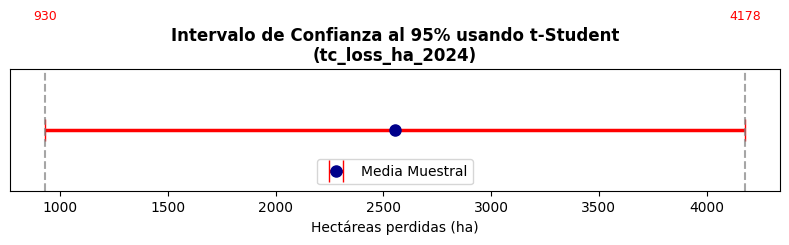

In [ ]:
# 6. GRAFICACIÓN CON plt.errorbar()
plt.figure(figsize=(8, 3))

# plt.errorbar dibuja el punto de la media y las barras horizontales del margen de error
plt.errorbar(x=media_muestral, y=1, xerr=margen_error, fmt='o', color='darkblue',
             ecolor='red', elinewidth=2.5, capsize=8, markersize=8, label='Media Muestral')

# Detalles estéticos del gráfico
plt.axvline(x=limite_inferior, color='grey', linestyle='--', alpha=0.7)
plt.axvline(x=limite_superior, color='grey', linestyle='--', alpha=0.7)
plt.text(limite_inferior, 1.1, f'{limite_inferior:.0f}', color='red', ha='center', fontsize=9)
plt.text(limite_superior, 1.1, f'{limite_superior:.0f}', color='red', ha='center', fontsize=9)

plt.yticks([]) # Ocultar el eje Y ya que solo sirve de apoyo
plt.xlabel('Hectáreas perdidas (ha)')
dist_name = "Z" if n >= 30 else "t-Student"
plt.title(f'Intervalo de Confianza al 95% usando {dist_name}\n({variable_cuantitativa})', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

####**¿Qué ocurre en la gráfica?**
La función plt.errorbar() toma el valor de la media (x=media_muestral), lo sitúa de forma arbitraria en el eje Y (y=1) y dibuja una barra de error horizontal (xerr=margen_error) pintada de rojo hacia ambos lados
. Los topes ("caps") de las barras rojas marcan visualmente los límites exactos dentro de los cuales se espera que esté la media real de la deforestación forestal ecuatoriana bajo el nivel de confianza establecido.

# **Tarea 4: ABI - El Impacto del Nivel de Confianza $$(1 - \alpha)$$**


--- Resultados del Cálculo ---
Nivel de Confianza 80%: Margen de Error = ±5.24 kWh
Nivel de Confianza 90%: Margen de Error = ±6.72 kWh
Nivel de Confianza 95%: Margen de Error = ±8.01 kWh
Nivel de Confianza 99%: Margen de Error = ±10.53 kWh


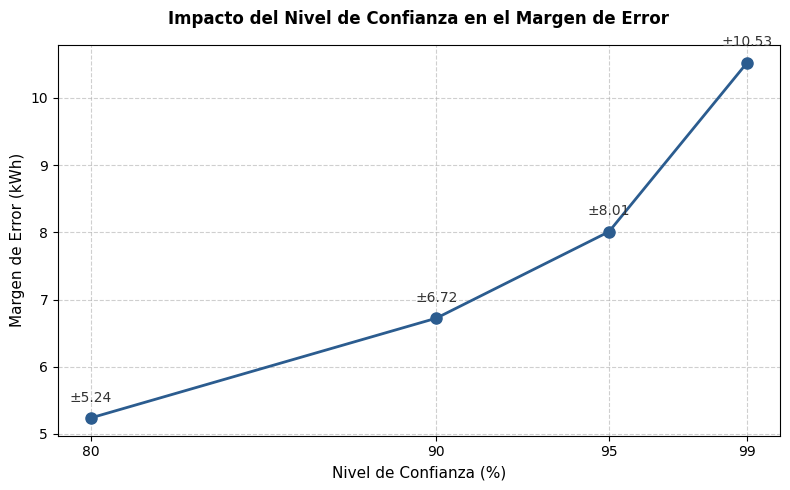

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Recreación de los datos de la muestra (Tarea 1)
np.random.seed(42)
n_grande = 100
muestra_consumo = np.random.normal(loc=350, scale=45, size=n_grande)

# Estadísticos base
desv_estandar = np.std(muestra_consumo, ddof=1) # s (muestral)
error_estandar = desv_estandar / np.sqrt(n_grande) # SE

# Niveles de confianza solicitados
niveles_confianza = [0.80, 0.90, 0.95, 0.99]
margenes_error = []

# Bucle para calcular el margen de error para cada nivel de confianza
print("--- Resultados del Cálculo ---")
for nc in niveles_confianza:
    ic_inferior, ic_superior = norm.interval(confidence=nc, loc=np.mean(muestra_consumo), scale=error_estandar)
    me = (ic_superior - ic_inferior) / 2
    margenes_error.append(me)
    print(f"Nivel de Confianza {nc*100:.0f}%: Margen de Error = ±{me:.2f} kWh")

# 2. Generación del gráfico de líneas
plt.figure(figsize=(8, 5))
plt.plot([nc * 100 for nc in niveles_confianza], margenes_error, marker='o', color='#2b5c8f', linewidth=2, markersize=8)
plt.title('Impacto del Nivel de Confianza en el Margen de Error', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Nivel de Confianza (%)', fontsize=11)
plt.ylabel('Margen de Error (kWh)', fontsize=11)
plt.xticks([nc * 100 for nc in niveles_confianza])
plt.grid(True, linestyle='--', alpha=0.6)

# Añadir etiquetas con los valores exactos sobre los puntos
for x, y in zip(niveles_confianza, margenes_error):
    plt.text(x * 100, y + 0.2, f'±{y:.2f}', ha='center', va='bottom', fontsize=10, color='#333333')

plt.tight_layout()
plt.show()

## **Por qué el 95% es el estándar de la industria en lugar del 99%**

## 1. Relación Observada entre el Nivel de Confianza y el Margen de Error

A partir de los cálculos realizados sobre la muestra de consumo energético ($n = 100$), se observan los siguientes resultados:
* **NC 80%:** Margen de Error = $\pm 5.24$ kWh
* **NC 90%:** Margen de Error = $\pm 6.72$ kWh
* **NC 95%:** Margen de Error = $\pm 8.01$ kWh *(Dato obtenido originalmente en Tarea 1)*
* **NC 99%:** Margen de Error = $\pm 10.53$ kWh

**Conclusión Analítica:** Existe una **relación directa y proporcional** entre el nivel de confianza y el margen de error. A medida que exigimos una mayor certeza estadística (un nivel de confianza más alto), el margen de error aumenta notablemente. Visualmente, esto se traduce en que las "barras de error" o los intervalos se vuelven más anchos.

---

## 2. Perspectiva de Toma de Decisiones: ¿Por qué el 95% es el estándar frente al 99%?

En el ámbito empresarial y de analítica de negocios (ABI), la selección del nivel de confianza no es solo un criterio matemático, sino un **equilibrio estratégico entre precisión y certeza**.

El **95% se ha consolidado como el estándar de la industria** por las siguientes razones de negocio:

#### A. El Costo de la Certeza Excesiva (El Principio de Rendimientos Decrecientes)
Para pasar de un nivel de confianza del 95% al 99%, incrementamos nuestra certeza en apenas un **4%**. Sin embargo, penalizamos la precisión del negocio incrementando el margen de error en un **31.4%** (pasando de un error de $\pm 8.01$ kWh a un error de $\pm 10.53$ kWh). En la práctica, un intervalo demasiado amplio reduce la utilidad de la estimación para planificar presupuestos o infraestructura.

#### B. Impacto Operativo en la Toma de Decisiones
* **Con el 95% de confianza:** El intervalo de estimación es lo suficientemente estrecho para tomar decisiones operativas concretas (por ejemplo, optimizar la compra de energía sabiendo que el margen de fluctuación está acotado).
* **Con el 99% de confianza:** El intervalo se vuelve tan amplio que puede paralizar la toma de decisiones. Si el rango estimado de consumo de un recurso es sumamente vago, la estimación pierde valor estratégico.

#### C. El Costo Económico del Tamaño Muestral ($n$)
Si un tomador de decisiones exigiera mantener un margen de error pequeño (digamos, de $\pm 8.01$ kWh) pero elevando la certeza al 99%, la única solución matemática sería **aumentar masivamente el tamaño de la muestra ($n$)**. En proyectos reales, recolectar, auditar y procesar más datos implica un costo financiero y de tiempo considerable.

### Conclusión
El estándar del **95%** representa el "punto óptimo" (*sweet spot*) donde el riesgo de equivocarse es controlado (solo 5% de probabilidad de que el verdadero parámetro esté fuera del intervalo), sin sacrificar la precisión técnica y sin disparar los costos de adquisición de datos que requeriría un nivel del 99%. El 99% se reserva únicamente para escenarios críticos donde un error cuesta vidas humanas o fallos catastróficos (ej. medicina, aeronáutica o ingeniería estructural).

# **Preguntas de Control**

**Defina con precisión técnica la diferencia conceptual entre una estimación puntual y una estimación por intervalos. ¿Por qué la estimación puntual por sí sola es insuficiente en ingeniería?**

> La estimación de parámetros es el procedimiento mediante el cual se busca aproximar los valores fijos, pero generalmente desconocidos, que describen a una población (como la media verdadera μ o la desviación estándar σ) utilizando estadísticos calculados a partir de los datos de la muestra
. Esta estimación comienza con la **estimación puntual**, que consiste en utilizar un solo valor numérico extraído de la muestra para aproximarse al parámetro poblacional. Por ejemplo, se utiliza la media muestral (x) para estimar la media de la población (μ), o la desviación estándar muestral (s) para estimar la desviación estándar poblacional (σ).

>Sin embargo, la limitación fundamental de la estimación puntual es que un punto numérico aislado no proporciona información sobre el margen de error ni indica el nivel de confianza que se puede tener en dicho cálculo. Para resolver este problema, la estadística recurre a la estimación por intervalos.

>Una **estimación por intervalo** determina un rango o límite de valores dentro del cual se esperaría encontrar el verdadero parámetro de la población. La estructura matemática general de un intervalo de confianza (IC) se define como el estimador puntual sumado y restado por el producto de un valor crítico y el error estándar.


**• Explique la interpretación frecuentista correcta de un Intervalo de Confianza del 95%. (Evite el error común de decir "hay un 95% de probabilidad de que caiga aquí").**

>Es imperativo interpretar los intervalos de confianza correctamente desde una perspectiva científica. Un intervalo de confianza del 95%, por ejemplo, no significa que haya un 95% de probabilidad de que el parámetro fijo se encuentre dentro de ese intervalo específico; el parámetro poblacional no es una variable, por lo que simplemente está o no está dentro de dicho límite.

>La interpretación teórica precisa es que, si se repitiera el proceso de muestreo múltiples veces bajo las mismas condiciones y se construyeran 100 intervalos distintos, se esperaría que aproximadamente 95 de esos intervalos contengan el verdadero parámetro poblacional.

• **Al comparar las distribuciones Z Normal Estándar y la de Student, ¿qué característica visual y matemática de la campana de la de Student la hace idónea para compensar la falta de información en muestras pequeñas?**
>La distribución t de Student es simétrica y tiene forma de campana al igual que la distribución normal estándar. Sin embargo, al depender de las fluctuaciones de dos estadísticos muestrales simultáneamente (la media y la varianza), incorpora una mayor incertidumbre. Para compensarlo, la distribución t es más "conservadora", poseyendo colas más anchas que la campana de Gauss normal. Esto genera intencionalmente intervalos de confianza un poco más amplios para proteger el análisis frente a la falta de información poblacional perfecta.


**• Si en su Proyecto Integrador (Tarea 3) usted deseara reducir el Margen de Error a la mitad sin disminuir su Nivel de Confianza (manteniéndolo al 95%), ¿qué debe hacer metodológicamente con su recolección de datos ()? Apóyese en la fórmula.**

>Para comprender la acción metodológica exacta que se debe tomar, es indispensable analizar la estructura matemática que rige la estimación de parámetros. El margen de error (e) se define como el producto del valor crítico de la distribución y el error estándar de la muestra, estructurándose mediante la siguiente fórmula:
 $$E = Z_{\alpha/2} \cdot \frac{\sigma}{\sqrt{n}}$$

>Si reorganizamos algebraicamente esta ecuación para despejar la variable del tamaño muestral (n) en función del error exigido, obtenemos la ecuación rectora de la planificación muestral:
$$n = \left( \frac{Z_{\alpha/2} \cdot \sigma}{E} \right)^2$$

>En el escenario propuesto, al mantener el nivel de confianza estático en un 95%, el valor crítico se convierte en una constante matemática fija.  Paralelamente, la desviación estándar (σ) representa la variabilidad intrínseca y natural de la población bajo estudio, por lo cual también permanece constante. Al aislar ambas constantes, se revela que el margen de error mantiene una relación inversamente proporcional estrictamente vinculada a la raíz cuadrada del tamaño de la muestra.


>**Demostración Matemática**

>Si queremos que el nuevo error ($E_2$) sea la mitad del original ($E_1 / 2$):

$$n_2 = \left( \frac{Z_{\alpha/2} \cdot \sigma}{E_1 / 2} \right)^2$$
$$n_2 = \left( 2 \cdot \frac{Z_{\alpha/2} \cdot \sigma}{E_1} \right)^2$$
$$n_2 = 2^2 \cdot \left( \frac{Z_{\alpha/2} \cdot \sigma}{E_1} \right)^2$$

>Dado que el término entre paréntesis es $n_1$, concluimos que:
$$n_2 = 4 \cdot n_1$$


>Metodológica y Operativa Los modelos matemáticos demuestran de forma concluyente que, metodológicamente, no basta con recolectar el doble de datos. Para lograr reducir el margen de error a la mitad conservando el mismo nivel de confianza, el investigador está obligado a cuadruplicar (incrementar 4 veces) el tamaño de la muestra. Esta imposición matemática obedece a un comportamiento geométrico conocido como decaimiento asintótico inverso. A nivel de gestión y diseño de proyectos, este fenómeno introduce la Ley de los Rendimientos Decrecientes en la recolección de información. Significa que la ganancia en precisión estadística no tiene un crecimiento lineal; al crecer al ritmo de una raíz cuadrada, cualquier mejora en la exactitud del estudio penaliza el proceso exigiendo una inversión cuadrática y masiva en los recursos, el tiempo y el presupuesto necesarios para levantar la nueva muestra.


**• Basado en su gráfico de la Tarea 4, ¿qué ocurre con el Intervalo de Confianza si buscamos un de certeza teórica?**

>Si intentamos alcanzar el 100% de certeza absoluta, el Intervalo de Confianza se vuelve infinito. Como se observa en la tendencia de tu gráfica, a medida que la confianza crece (del 80% al 99%), la curva del margen de error se dispara hacia arriba. Matemáticamente, para un 100% de confianza, el valor crítico Z (o t) tiende a infinito (∞). Al multiplicar por infinito en la fórmula, el Margen de Error se vuelve infinito y nuestro intervalo abarcaría desde −∞ hasta +∞.


>**¿Tiene esto alguna utilidad analítica real para su proyecto en Loja?***

>No, tiene una utilidad analítica completamente nula, por dos grandes razones que destruyen el análisis:
- *Parálisis en la toma de decisiones:* Como se demostró en el texto anterior, un intervalo demasiado amplio paraliza cualquier acción estratégica. Si le decimos a las autoridades ambientales que "estamos 100% seguros de que la deforestación en Loja estará entre menos infinito y más infinito de hectáreas", la estimación pierde todo su valor predictivo y no sirve para asignar presupuestos, recursos ni personal de control forestal.
- Violación de los Rangos Teóricos: Un límite infinito entra en conflicto directo con los límites lógicos y físicos de la geografía. Como se estableció en la investigación, la variable continua de pérdida de cobertura arbórea (tc_loss_ha_2024) tiene un espacio muestral restringido: es físicamente imposible registrar una pérdida de hectáreas superior a la cvobertura forestal inicial existente (Extent_2000_ha) o al área total de la provincia (Area_ha). Un intervalo de confianza infinito ignoraría estas leyes físicas.

>En resumen: En la estadística aplicada a la ingeniería y ciencias ambientales, sacrificar toda la precisión (margen de error infinito) a cambio de una "certeza teórica absoluta" (100%) destruye la utilidad matemática y física del modelo. Por eso los investigadores se detienen en el "punto óptimo" del 95%.